<a href="https://colab.research.google.com/github/evinracher/3010090-ontological-engineering/blob/main/week5/1_OCR_RAG_Pipeline_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Pipeline OCR + RAG con LangChain, ChromaDB y Groq

Este notebook implementa un pipeline completo que:

1. 📄 **Extrae texto de imágenes/PDFs** usando `pytesseract` + `pdf2image`
2. 🧩 **Genera embeddings** con un modelo de HuggingFace
3. 🗄️ **Almacena en ChromaDB** como base de conocimiento vectorial
4. 🤖 **Responde preguntas** usando un modelo de Groq (LLaMA / Mixtral)
5. 🔗 **Todo orquestado con LangChain**

---
**Arquitectura del pipeline:**
```
PDF/Imagen → pdf2image → pytesseract → Chunks → HuggingFace Embeddings → ChromaDB
                                                                              ↓
Pregunta del usuario ──────────────────────────────────────────────→ Retriever
                                                                              ↓
                                                                    Groq LLM → Respuesta
```

## 📦 Sección 1: Instalación de dependencias

Instalamos todas las librerías necesarias. Nota: `tesseract-ocr` y `poppler-utils` son dependencias del sistema.

In [ ]:
# ── Dependencias del sistema ──────────────────────────────────────────────────
# tesseract-ocr  → motor OCR
# tesseract-ocr-spa → soporte para español
# poppler-utils  → necesario para pdf2image (convierte PDF a imágenes)
!apt-get install -y tesseract-ocr tesseract-ocr-spa poppler-utils 2>/dev/null | tail -5

# ── Dependencias de Python ────────────────────────────────────────────────────
!pip install -q \
    pytesseract \
    pdf2image \
    Pillow \
    langchain \
    langchain-community \
    langchain-huggingface \
    langchain-groq \
    langchain-chroma \
    chromadb \
    sentence-transformers \
    groq

print("✅ Todas las dependencias instaladas correctamente")

Preparing to unpack .../tesseract-ocr-spa_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.5 MB/s eta 0:0

## 📚 Sección 2: Imports y configuración inicial

In [ ]:
import os
import re
from pathlib import Path
from typing import List
from google.colab import files, userdata
# OCR
import pytesseract
from PIL import Image
from pdf2image import convert_from_path, convert_from_bytes

# LangChain
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Embeddings (HuggingFace)
from langchain_huggingface import HuggingFaceEmbeddings

# Vector Store
from langchain_chroma import Chroma

# LLM (Groq)
from langchain_groq import ChatGroq

# Utilidades
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports completados")

✅ Imports completados


## 🔑 Sección 3: Configuración de la API Key de Groq

Obtén tu API key gratuita en: https://console.groq.com

> 💡 **Tip de seguridad:** Usa `getpass` para no exponer tu key en el notebook.

In [ ]:
try:
    apikey = userdata.get('GROQ_API_KEY')
    os.environ["GROQ_API_KEY"] = apikey
    print("API Key configurada correctamente.")
except:
    print("Error: No se encontró la API Key. Asegúrate de agregarla en Secrets.")

API Key configurada correctamente.


## 🖼️ Sección 4: Módulo OCR — Extracción de texto

Implementamos funciones para:
- Extraer texto de una imagen directa
- Convertir PDF a imágenes con `pdf2image` y luego aplicar OCR
- Preprocesar el texto extraído

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MÓDULO OCR
# ─────────────────────────────────────────────────────────────────────────────

def configurar_tesseract():
    """
    Detecta y configura la ruta de Tesseract.
    En Colab normalmente se instala en /usr/bin/tesseract.
    """
    rutas_posibles = [
        '/usr/bin/tesseract',
        '/usr/local/bin/tesseract',
        r'C:\Program Files\Tesseract-OCR\tesseract.exe',  # Windows
    ]
    for ruta in rutas_posibles:
        if os.path.exists(ruta):
            pytesseract.pytesseract.tesseract_cmd = ruta
            print(f"✅ Tesseract encontrado en: {ruta}")
            print(f"   Versión: {pytesseract.get_tesseract_version()}")
            return True
    print("⚠️  No se encontró Tesseract. Verifica la instalación.")
    return False


def limpiar_texto(texto: str) -> str:
    """
    Limpia el texto extraído por OCR:
    - Elimina líneas vacías excesivas
    - Corrige espacios múltiples
    - Elimina caracteres de control
    """
    # Eliminar caracteres de control excepto saltos de línea
    texto = re.sub(r'[^\S\n]+', ' ', texto)
    # Reducir múltiples saltos de línea a máximo 2
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    # Eliminar espacios al inicio/fin de cada línea
    lineas = [linea.strip() for linea in texto.split('\n')]
    texto = '\n'.join(lineas)
    return texto.strip()


def ocr_desde_imagen(imagen: Image.Image, idioma: str = 'spa+eng') -> str:
    """
    Aplica OCR a un objeto PIL Image.

    Args:
        imagen: Objeto PIL Image
        idioma: Idioma(s) para Tesseract. 'spa+eng' para español e inglés.
                Otros: 'eng' (solo inglés), 'spa' (solo español)

    Returns:
        Texto extraído y limpiado
    """
    # Configuración de Tesseract:
    # --psm 3: Segmentación automática de página (por defecto, recomendado)
    # --oem 3: Motor LSTM + legacy (mejor precisión)
    config_tesseract = '--psm 3 --oem 3'

    texto = pytesseract.image_to_string(
        imagen,
        lang=idioma,
        config=config_tesseract
    )
    return limpiar_texto(texto)


def ocr_desde_archivo_imagen(ruta_imagen: str, idioma: str = 'spa+eng') -> str:
    """
    Carga una imagen desde disco y aplica OCR.

    Args:
        ruta_imagen: Ruta al archivo de imagen (JPG, PNG, TIFF, BMP, etc.)
        idioma: Idioma para Tesseract

    Returns:
        Texto extraído
    """
    imagen = Image.open(ruta_imagen)
    # Convertir a RGB si es necesario (evita problemas con RGBA o escala de grises)
    if imagen.mode != 'RGB':
        imagen = imagen.convert('RGB')
    texto = ocr_desde_imagen(imagen, idioma)
    print(f"📄 Imagen procesada: {ruta_imagen} ({len(texto)} caracteres extraídos)")
    return texto


def ocr_desde_pdf(ruta_pdf: str, idioma: str = 'spa+eng', dpi: int = 300) -> List[str]:
    """
    Convierte un PDF a imágenes con pdf2image y aplica OCR página por página.

    ¿Por qué pdf2image?
    - Evita problemas con PDFs escaneados (no tienen texto embebido)
    - Maneja PDFs con imágenes, tablas y layouts complejos
    - Convierte cada página a una imagen de alta calidad para mejor OCR

    Args:
        ruta_pdf: Ruta al archivo PDF
        idioma: Idioma para Tesseract
        dpi: Resolución de conversión (300 DPI = buena calidad/velocidad)

    Returns:
        Lista con el texto de cada página
    """
    print(f"🔄 Convirtiendo PDF a imágenes con pdf2image (DPI={dpi})...")

    # convert_from_path: convierte cada página del PDF en una imagen PIL
    paginas = convert_from_path(
        ruta_pdf,
        dpi=dpi,
        fmt='jpeg',          # Formato de imagen intermedio
        thread_count=2,      # Procesamiento paralelo
    )

    print(f"📑 Total de páginas detectadas: {len(paginas)}")

    textos_por_pagina = []
    for num_pagina, pagina_img in enumerate(paginas, start=1):
        print(f"   ⚙️  Aplicando OCR a página {num_pagina}/{len(paginas)}...", end=' ')
        texto = ocr_desde_imagen(pagina_img, idioma)
        textos_por_pagina.append(texto)
        print(f"({len(texto)} chars)")

    print(f"\n✅ OCR completado. Total caracteres: {sum(len(t) for t in textos_por_pagina)}")
    return textos_por_pagina


def ocr_desde_pdf_bytes(pdf_bytes: bytes, idioma: str = 'spa+eng', dpi: int = 300) -> List[str]:
    """
    Aplica OCR a un PDF cargado desde bytes (útil para uploads en Colab).
    """
    paginas = convert_from_bytes(pdf_bytes, dpi=dpi, fmt='jpeg')
    textos = [ocr_desde_imagen(p, idioma) for p in paginas]
    return textos


# Configurar Tesseract al cargar el módulo
configurar_tesseract()

✅ Tesseract encontrado en: /usr/bin/tesseract
   Versión: 4.1.1


True

## 📝 Sección 5: Creación de documentos de prueba

Generamos imágenes de texto sintéticas para demostrar el pipeline sin necesidad de archivos externos.

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import textwrap

# ─────────────────────────────────────────────────────────────────────────────
# Crear imágenes de ejemplo con texto sobre Inteligencia Artificial
# ─────────────────────────────────────────────────────────────────────────────

DOCUMENTOS_EJEMPLO = [
    {
        "titulo": "Documento 1: Historia de la Inteligencia Artificial",
        "contenido": """
Historia de la Inteligencia Artificial

La inteligencia artificial (IA) es una rama de la informatica que
busca crear sistemas capaces de realizar tareas que normalmente
requieren inteligencia humana.

En 1950, Alan Turing propuso el famoso Test de Turing para evaluar
si una maquina puede exhibir un comportamiento inteligente. Este
hito marco el inicio formal de la disciplina.

En 1956, John McCarthy acuno el termino Inteligencia Artificial
durante la Conferencia de Dartmouth, considerada el nacimiento
oficial del campo.

Durante los anos 1980, las redes neuronales resurgen gracias al
algoritmo de backpropagation desarrollado por Rumelhart y Hinton.
        """
    },
    {
        "titulo": "Documento 2: Machine Learning",
        "contenido": """
Machine Learning: Aprendizaje Automatico

El Machine Learning es un subcampo de la IA que permite a los
sistemas aprender y mejorar automaticamente a partir de la
experiencia sin ser programados explicitamente.

Tipos principales de aprendizaje:

1. Aprendizaje Supervisado: El modelo aprende con datos etiquetados.
   Ejemplos: clasificacion de emails, prediccion de precios.

2. Aprendizaje No Supervisado: Descubre patrones sin etiquetas.
   Ejemplos: clustering, reduccion de dimensionalidad.

3. Aprendizaje por Refuerzo: El agente aprende mediante prueba
   y error con recompensas. Ejemplo: AlphaGo de DeepMind.
        """
    },
    {
        "titulo": "Documento 3: Modelos de Lenguaje",
        "contenido": """
Modelos de Lenguaje de Gran Escala (LLMs)

Los Large Language Models son redes neuronales entrenadas con
enormes cantidades de texto para comprender y generar lenguaje
natural con alta precision.

GPT-4 de OpenAI fue lanzado en 2023 y puede realizar tareas
complejas de razonamiento, codigo y analisis de imagenes.

LLaMA de Meta es un modelo open-source disponible para
investigadores y desarrolladores sin costo.

Groq es una plataforma de inferencia ultra-rapida que permite
ejecutar modelos como LLaMA y Mixtral con latencias muy bajas,
ideal para aplicaciones en tiempo real.
        """
    }
]


def crear_imagen_con_texto(texto: str, nombre_archivo: str, ancho: int = 900, alto: int = 700):
    """
    Crea una imagen PNG con texto negro sobre fondo blanco.
    Simula un documento escaneado o fotografiado.
    """
    imagen = Image.new('RGB', (ancho, alto), color='white')
    draw = ImageDraw.Draw(imagen)

    # Usar fuente por defecto de PIL
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18)
        font_bold = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
    except:
        font = ImageFont.load_default()
        font_bold = font

    # Dividir texto en líneas
    margen = 40
    y_pos = margen
    lineas = texto.strip().split('\n')

    for i, linea in enumerate(lineas):
        # Primera línea = título en negrita
        fuente_actual = font_bold if i == 0 else font
        # Envolver líneas largas
        if len(linea) > 70:
            sublineas = textwrap.wrap(linea, width=70)
        else:
            sublineas = [linea]

        for sublinea in sublineas:
            if y_pos > alto - margen:
                break
            draw.text((margen, y_pos), sublinea, fill='black', font=fuente_actual)
            y_pos += 28

    imagen.save(nombre_archivo, 'PNG')
    return nombre_archivo


# Crear las imágenes de ejemplo
os.makedirs('/content/imagenes_ejemplo', exist_ok=True)
rutas_imagenes = []

for i, doc in enumerate(DOCUMENTOS_EJEMPLO):
    ruta = f"/content/imagenes_ejemplo/documento_{i+1}.png"
    crear_imagen_con_texto(doc["contenido"], ruta)
    rutas_imagenes.append(ruta)
    print(f"✅ Creado: {ruta}")

print(f"\n📁 {len(rutas_imagenes)} imágenes de ejemplo listas")

✅ Creado: /content/imagenes_ejemplo/documento_1.png
✅ Creado: /content/imagenes_ejemplo/documento_2.png
✅ Creado: /content/imagenes_ejemplo/documento_3.png

📁 3 imágenes de ejemplo listas


## 👀 Sección 6: Visualizar y aplicar OCR a las imágenes

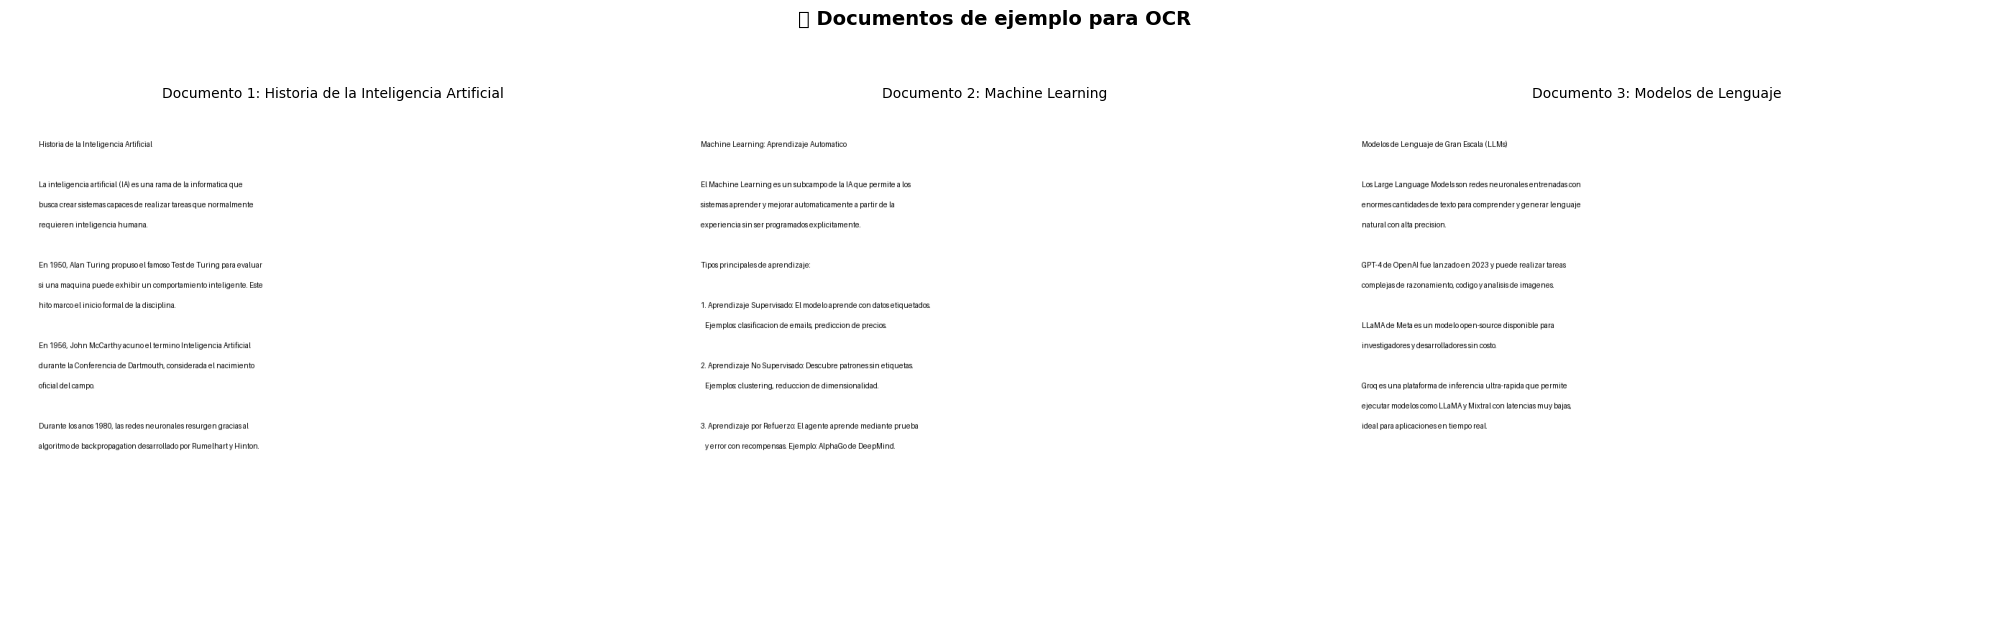

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Mostrar las imágenes creadas
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for i, ruta in enumerate(rutas_imagenes):
    img = mpimg.imread(ruta)
    axes[i].imshow(img)
    axes[i].set_title(DOCUMENTOS_EJEMPLO[i]['titulo'], fontsize=10, pad=10)
    axes[i].axis('off')
plt.suptitle('📄 Documentos de ejemplo para OCR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# APLICAR OCR A TODAS LAS IMÁGENES
# ─────────────────────────────────────────────────────────────────────────────

textos_extraidos = []

for i, ruta in enumerate(rutas_imagenes):
    print(f"\n{'='*60}")
    print(f"🔍 Procesando: {ruta}")
    texto = ocr_desde_archivo_imagen(ruta, idioma='spa+eng')
    textos_extraidos.append(texto)

    # Mostrar preview del texto extraído
    preview = texto[:200] + '...' if len(texto) > 200 else texto
    print(f"\n📝 Preview del texto extraído:")
    print(f"   {preview}")

print(f"\n{'='*60}")
print(f"\n✅ OCR completado para {len(textos_extraidos)} documentos")


🔍 Procesando: /content/imagenes_ejemplo/documento_1.png
📄 Imagen procesada: /content/imagenes_ejemplo/documento_1.png (637 caracteres extraídos)

📝 Preview del texto extraído:
   Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que
busca ctear sistemas capaces de realizar tareasque normalmente

requieren inteligencia humana,

En 1...

🔍 Procesando: /content/imagenes_ejemplo/documento_2.png
📄 Imagen procesada: /content/imagenes_ejemplo/documento_2.png (583 caracteres extraídos)

📝 Preview del texto extraído:
   Machine Learning: Aprendizaje Automatico

El Machine Learningesun subcampode la lAque permite los

sstemasaprendery mejorar automaticamente a partir dela

experiencia sin ser programados explicitament...

🔍 Procesando: /content/imagenes_ejemplo/documento_3.png
📄 Imagen procesada: /content/imagenes_ejemplo/documento_3.png (557 caracteres extraídos)

📝 Preview del texto extraído:
   Modelosde Lenguaje de Gran Escala (LLMs)

Los Large 

## 🔬 Sección 7 (Bonus): OCR desde un PDF

Demo de cómo procesar un PDF subido a Colab usando `pdf2image`.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SUBIR DOCUMENTOS (PDF O IMÁGENES)
# ─────────────────────────────────────────────────────────────────────────────

USAR_ARCHIVOS_PROPIOS = True

EXT_IMAGEN = (".png", ".jpg", ".jpeg", ".webp", ".tiff", ".bmp")

if USAR_ARCHIVOS_PROPIOS:

    from google.colab import files
    import io
    from PIL import Image

    print("📤 Sube archivos (PDF o imágenes):")

    archivos_subidos = files.upload()

    for nombre_archivo, contenido in archivos_subidos.items():

        nombre = nombre_archivo.lower()

        # ───────── PDF ─────────
        if nombre.endswith(".pdf"):

            print(f"\n📄 Procesando PDF: {nombre_archivo}")

            textos_pdf = ocr_desde_pdf_bytes(
                contenido,
                idioma="spa+eng",
                dpi=200
            )

            textos_extraidos.extend(textos_pdf)

            print(f"✅ {len(textos_pdf)} páginas del PDF agregadas al corpus")

        # ───────── IMAGEN ─────────
        elif nombre.endswith(EXT_IMAGEN):

            print(f"\n🖼️ Procesando imagen: {nombre_archivo}")

            imagen = Image.open(io.BytesIO(contenido))

            texto = pytesseract.image_to_string(
                imagen,
                lang="spa+eng"
            )

            textos_extraidos.append(texto)

            print("✅ Texto extraído de la imagen agregado al corpus")

        else:

            print(f"⚠️ Archivo ignorado (tipo no soportado): {nombre_archivo}")

else:

    print("ℹ️  Demo de carga de archivos omitida.")


# ─────────────────────────────────────────────────────────────────────────────
# OPCIÓN B: Crear un PDF de prueba con reportlab (opcional)
# ─────────────────────────────────────────────────────────────────────────────
CREAR_PDF_DEMO = False  # Cambiar a True para probar el flujo PDF completo

if CREAR_PDF_DEMO:
    !pip install -q reportlab
    from reportlab.pdfgen import canvas
    from reportlab.lib.pagesizes import A4

    def crear_pdf_demo(ruta: str):
        c = canvas.Canvas(ruta, pagesize=A4)
        ancho, alto = A4
        # Página 1
        c.setFont('Helvetica-Bold', 16)
        c.drawString(72, alto - 80, "Documento PDF de Prueba")
        c.setFont('Helvetica', 12)
        texto_p1 = [
            "Este es un PDF de ejemplo para demostrar el pipeline OCR.",
            "Groq ofrece inferencia de LLMs a velocidades muy altas.",
            "ChromaDB es una base de datos vectorial open-source.",
            "LangChain facilita la construccion de aplicaciones con LLMs.",
        ]
        y = alto - 120
        for linea in texto_p1:
            c.drawString(72, y, linea)
            y -= 24
        c.showPage()
        # Página 2
        c.setFont('Helvetica-Bold', 14)
        c.drawString(72, alto - 80, "Pagina 2: Embeddings y RAG")
        c.setFont('Helvetica', 12)
        texto_p2 = [
            "RAG significa Retrieval Augmented Generation.",
            "Los embeddings son representaciones vectoriales del texto.",
            "Sentence Transformers genera embeddings de alta calidad.",
        ]
        y = alto - 120
        for linea in texto_p2:
            c.drawString(72, y, linea)
            y -= 24
        c.save()

    ruta_pdf_demo = '/content/pdf_demo.pdf'
    crear_pdf_demo(ruta_pdf_demo)
    print(f"📄 PDF de demo creado: {ruta_pdf_demo}")

    textos_pdf = ocr_desde_pdf(ruta_pdf_demo, idioma='eng', dpi=200)
    textos_extraidos.extend(textos_pdf)
    print(f"✅ {len(textos_pdf)} páginas del PDF demo agregadas")

📤 Sube archivos (PDF o imágenes):


Saving 68f8bb40b6ef7dacd61eac1d_unnamed-3.jpeg to 68f8bb40b6ef7dacd61eac1d_unnamed-3 (1).jpeg

🖼️ Procesando imagen: 68f8bb40b6ef7dacd61eac1d_unnamed-3 (1).jpeg
✅ Texto extraído de la imagen agregado al corpus


## 🧩 Sección 8: Chunking — División del texto en fragmentos

Dividimos el texto en fragmentos (chunks) para una recuperación más precisa.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONVERTIR TEXTOS A DOCUMENTOS LANGCHAIN + CHUNKING
# ─────────────────────────────────────────────────────────────────────────────

# Parámetros del splitter
CHUNK_SIZE = 500       # Tamaño de cada fragmento en caracteres
CHUNK_OVERLAP = 100   # Solapamiento entre chunks (mantiene contexto entre fragmentos)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']  # Jerarquía de separadores
)

# Crear documentos LangChain con metadatos
documentos_langchain = []

for i, texto in enumerate(textos_extraidos):
    if not texto.strip():
        print(f"⚠️  Documento {i+1} vacío, saltando...")
        continue

    fuente = f"imagen_{i+1}.png" if i < len(rutas_imagenes) else f"pdf_pagina_{i-len(rutas_imagenes)+1}"

    # Crear un Document de LangChain con metadatos
    doc = Document(
        page_content=texto,
        metadata={
            "fuente": fuente,
            "indice_documento": i,
            "titulo": DOCUMENTOS_EJEMPLO[i]["titulo"] if i < len(DOCUMENTOS_EJEMPLO) else "Página PDF",
            "num_caracteres": len(texto)
        }
    )
    documentos_langchain.append(doc)

# Dividir en chunks
chunks = text_splitter.split_documents(documentos_langchain)

print(f"📊 Estadísticas del chunking:")
print(f"   Documentos originales : {len(documentos_langchain)}")
print(f"   Chunks generados      : {len(chunks)}")
print(f"   Chunk size máximo     : {CHUNK_SIZE} chars")
print(f"   Chunk overlap         : {CHUNK_OVERLAP} chars")
print(f"\n🔍 Ejemplo de chunk:")
print(f"   Contenido: {chunks[0].page_content[:150]}...")
print(f"   Metadata:  {chunks[0].metadata}")

📊 Estadísticas del chunking:
   Documentos originales : 4
   Chunks generados      : 8
   Chunk size máximo     : 500 chars
   Chunk overlap         : 100 chars

🔍 Ejemplo de chunk:
   Contenido: Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que
busca ctear sistemas capaces de realizar tareasque...
   Metadata:  {'fuente': 'imagen_1.png', 'indice_documento': 0, 'titulo': 'Documento 1: Historia de la Inteligencia Artificial', 'num_caracteres': 637}


## 🤗 Sección 9: Embeddings con HuggingFace

Usamos `sentence-transformers` para generar representaciones vectoriales del texto.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODELO DE EMBEDDINGS
# ─────────────────────────────────────────────────────────────────────────────

# Modelos recomendados (de menor a mayor calidad/tamaño):
# - 'all-MiniLM-L6-v2'                → Rápido, 384 dims, buen para inglés
# - 'paraphrase-multilingual-MiniLM-L12-v2' → Multilingüe, 384 dims ✅ recomendado
# - 'sentence-transformers/LaBSE'     → Alta calidad multilingüe, 768 dims

MODELO_EMBEDDINGS = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

print(f"⬇️  Cargando modelo de embeddings: {MODELO_EMBEDDINGS}")
print("    (Primera ejecución puede tardar ~1 min para descargar el modelo)")

embeddings_model = HuggingFaceEmbeddings(
    model_name=MODELO_EMBEDDINGS,
    model_kwargs={'device': 'cpu'},  # Cambiar a 'cuda' si hay GPU disponible
    encode_kwargs={
        'normalize_embeddings': True,  # Normalizar para similitud coseno
        'batch_size': 32
    }
)

print(f"\n✅ Modelo cargado")

# Verificar dimensión de los embeddings
embedding_prueba = embeddings_model.embed_query("Texto de prueba para verificar dimensión")
print(f"📐 Dimensión del vector de embedding: {len(embedding_prueba)}")
print(f"   Primeros 5 valores: {[round(v, 4) for v in embedding_prueba[:5]]}")

⬇️  Cargando modelo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
    (Primera ejecución puede tardar ~1 min para descargar el modelo)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Modelo cargado
📐 Dimensión del vector de embedding: 384
   Primeros 5 valores: [-0.0144, 0.0584, -0.0452, -0.0195, -0.0243]


## 🗄️ Sección 10: Almacenamiento en ChromaDB

Creamos la base de datos vectorial con los chunks y sus embeddings.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CREAR VECTOR STORE EN CHROMADB
# ─────────────────────────────────────────────────────────────────────────────

CHROMA_PERSIST_DIR = '/content/chroma_db'  # Directorio de persistencia
COLLECTION_NAME = 'documentos_ocr'

print("🔄 Creando índice vectorial en ChromaDB...")
print(f"   Colección: {COLLECTION_NAME}")
print(f"   Chunks a indexar: {len(chunks)}")

# Crear el vector store (esto genera los embeddings y los almacena)
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings_model,
    collection_name=COLLECTION_NAME,
    persist_directory=CHROMA_PERSIST_DIR,
)

print(f"\n✅ ChromaDB creado y persistido en: {CHROMA_PERSIST_DIR}")
print(f"   Total de vectores almacenados: {vector_store._collection.count()}")


# ─────────────────────────────────────────────────────────────────────────────
# TEST DE BÚSQUEDA SEMÁNTICA DIRECTA
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("🔍 Test de búsqueda semántica en ChromaDB")
consulta_test = "¿Quién inventó el test de Turing?"
print(f"   Consulta: '{consulta_test}'")

resultados = vector_store.similarity_search_with_score(consulta_test, k=2)

for i, (doc, score) in enumerate(resultados):
    print(f"\n   Resultado {i+1} (score: {score:.4f}):")
    print(f"   Fuente: {doc.metadata.get('fuente', 'N/A')}")
    print(f"   Texto:  {doc.page_content[:200]}...")

🔄 Creando índice vectorial en ChromaDB...
   Colección: documentos_ocr
   Chunks a indexar: 8

✅ ChromaDB creado y persistido en: /content/chroma_db
   Total de vectores almacenados: 20

🔍 Test de búsqueda semántica en ChromaDB
   Consulta: '¿Quién inventó el test de Turing?'

   Resultado 1 (score: 0.6906):
   Fuente: imagen_1.png
   Texto:  Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que
busca ctear sistemas capaces de realizar tareasque normalmente

requieren inteligencia humana,

En 1...

   Resultado 2 (score: 0.6906):
   Fuente: imagen_1.png
   Texto:  Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que
busca ctear sistemas capaces de realizar tareasque normalmente

requieren inteligencia humana,

En 1...


## 🤖 Sección 11: LLM con Groq

Configuramos el modelo de lenguaje de Groq para la generación de respuestas.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURAR GROQ LLM
# ─────────────────────────────────────────────────────────────────────────────

# Modelos disponibles en Groq (Marzo 2025):
# - 'llama-3.3-70b-versatile'    → Mejor calidad, más lento
# - 'llama-3.1-8b-instant'       → Más rápido, buena calidad
# - 'mixtral-8x7b-32768'         → Ventana de contexto grande
# - 'gemma2-9b-it'               → Google Gemma 2

MODELO_GROQ = 'llama-3.3-70b-versatile'

llm = ChatGroq(
    model=MODELO_GROQ,
    temperature=0.1,          # Baja temperatura para respuestas más precisas/factuales
    max_tokens=1024,
    groq_api_key=os.environ.get("GROQ_API_KEY")
)

print(f"✅ Groq LLM configurado")
print(f"   Modelo : {MODELO_GROQ}")
print(f"   Temp   : 0.1 (respuestas deterministas y precisas)")

# Test rápido del LLM
print("\n🧪 Test del LLM:")
respuesta_test = llm.invoke("Responde en una sola oración: ¿Qué es la inteligencia artificial?")
print(f"   → {respuesta_test.content}")

✅ Groq LLM configurado
   Modelo : llama-3.3-70b-versatile
   Temp   : 0.1 (respuestas deterministas y precisas)

🧪 Test del LLM:
   → La inteligencia artificial (IA) se refiere a la creación de sistemas informáticos y algoritmos capaces de realizar tareas que normalmente requieren la inteligencia humana, como el aprendizaje, la resolución de problemas, la comprensión del lenguaje y la toma de decisiones.


## 🔗 Sección 12: Pipeline RAG completo con LangChain

Ensamblamos todos los componentes en una cadena de Retrieval-Augmented Generation.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PROMPT TEMPLATE PERSONALIZADO
# ─────────────────────────────────────────────────────────────────────────────

PROMPT_TEMPLATE = """
Eres un asistente experto que responde preguntas basándose EXCLUSIVAMENTE en el
contexto proporcionado. El contexto fue extraído de documentos mediante OCR.

INSTRUCCIONES:
- Responde de forma clara, concisa y en el mismo idioma de la pregunta.
- Si la información no está en el contexto, indica: "No encontré esa información en los documentos."
- Cita la fuente cuando sea posible (ej: "Según el Documento 1...").
- No inventes información que no esté en el contexto.

CONTEXTO RECUPERADO DE LOS DOCUMENTOS:
{context}

PREGUNTA: {question}

RESPUESTA:"""

prompt = PromptTemplate(
    template=PROMPT_TEMPLATE,
    input_variables=["context", "question"]
)


# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURAR RETRIEVER
# ─────────────────────────────────────────────────────────────────────────────

retriever = vector_store.as_retriever(
    search_type="similarity",  # Búsqueda por similitud coseno
    search_kwargs={
        "k": 4,  # Recuperar los 4 chunks más relevantes
    }
)


# ─────────────────────────────────────────────────────────────────────────────
# CREAR CADENA
# ─────────────────────────────────────────────────────────────────────────────

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Modificar rag_chain para devolver tanto la respuesta como los documentos fuente
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

rag_chain = (
    RunnableParallel(
        {
            "context": (lambda x: x["query"]) | retriever | format_docs,
            "question": RunnablePassthrough(),
            "source_documents": (lambda x: x["query"]) | retriever # También pasamos los documentos completos
        }
    )
    | prompt
    | llm
    | StrOutputParser()
)

print("✅ Pipeline RAG ensamblado con LangChain")
print("   Componentes:")
print("   1. Retriever  → ChromaDB (k=4 chunks)")
print("   2. LLM        → Groq (llama-3.3-70b-versatile)")
print("   3. Chain type → Stuff (concatenar contexto)")

✅ Pipeline RAG ensamblado con LangChain
   Componentes:
   1. Retriever  → ChromaDB (k=4 chunks)
   2. LLM        → Groq (llama-3.3-70b-versatile)
   3. Chain type → Stuff (concatenar contexto)


## 💬 Sección 13: ¡A preguntar! — Sesión de Q&A

Probamos el sistema con diferentes preguntas sobre los documentos.

In [ ]:
def preguntar(pregunta: str, mostrar_fuentes: bool = True):
    """
    Realiza una pregunta al sistema RAG y muestra la respuesta con formato.

    Args:
        pregunta: Pregunta en lenguaje natural
        mostrar_fuentes: Si True, muestra los chunks recuperados
    """
    print(f"\n{'='*65}")
    print(f"❓ PREGUNTA: {pregunta}")
    print('='*65)

    # The rag_chain now returns a dictionary with 'answer' and 'source_documents'
    # We need to invoke with a dictionary for the input, as the chain is expecting it
    chain_output = rag_chain.invoke({"query": pregunta})

    retrieved_docs = retriever.invoke(pregunta)

    print(f"\n🤖 RESPUESTA (Groq - {MODELO_GROQ}):")
    print(f"   {chain_output}")

    if mostrar_fuentes and retrieved_docs:
        print(f"\n📚 FUENTES RECUPERADAS ({len(retrieved_docs)} chunks):")
        for i, doc in enumerate(retrieved_docs, 1):
            fuente = doc.metadata.get('fuente', 'desconocida')
            titulo = doc.metadata.get('titulo', '')[:50]
            print(f"   [{i}] {fuente} | {titulo}")
            print(f"       Preview: {doc.page_content[:100].strip()}...")

    return chain_output


# ─────────────────────────────────────────────────────────────────────────────
# PREGUNTAS DE PRUEBA
# ─────────────────────────────────────────────────────────────────────────────

preguntas = [
    "¿Cuándo y por qué es importante el año 1950 en la historia de la IA?",
    "¿Qué es el aprendizaje por refuerzo y qué ejemplo se menciona?",
    "¿Qué ventajas ofrece Groq para los modelos de lenguaje?",
    "¿Qué es RAG y cómo se relaciona con los embeddings?",
    "¿Quién acuñó el término inteligencia artificial y cuándo?",
    "¿Tienes información de alguna factura?"
]

for pregunta in preguntas:
    preguntar(pregunta, mostrar_fuentes=True)


❓ PREGUNTA: ¿Cuándo y por qué es importante el año 1950 en la historia de la IA?

🤖 RESPUESTA (Groq - llama-3.3-70b-versatile):
   El año 1950 es importante en la historia de la IA porque, según el contexto, en ese año Alan Turing propuso el famoso Test de Turing para evaluar si una máquina puede exhibir un comportamiento inteligente. Este hito marcó el inicio formal de la disciplina de la Inteligencia Artificial.

📚 FUENTES RECUPERADAS (4 chunks):
   [1] imagen_1.png | Documento 1: Historia de la Inteligencia Artificia
       Preview: Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que...
   [2] imagen_1.png | Documento 1: Historia de la Inteligencia Artificia
       Preview: Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que...
   [3] imagen_1.png | Documento 1: Historia de la Inteligencia Artificia
       Preview: Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una 

## 🎮 Sección 14: Modo Interactivo

Haz tus propias preguntas en tiempo real.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAT INTERACTIVO
# Escribe 'salir' para terminar la sesión
# ─────────────────────────────────────────────────────────────────────────────

print("🎯 Modo interactivo activado")
print("   Escribe tus preguntas sobre los documentos procesados.")
print("   Escribe 'salir' para terminar.")
print("-" * 65)

while True:
    pregunta_usuario = input("\n💬 Tu pregunta: ").strip()

    if not pregunta_usuario:
        continue
    if pregunta_usuario.lower() in ['salir', 'exit', 'quit', 'q']:
        print("\n👋 Sesión terminada. ¡Hasta pronto!")
        break

    preguntar(pregunta_usuario, mostrar_fuentes=True)

## 🧪 Sección 15: Explorar ChromaDB

Inspecciona los vectores almacenados y experimenta con búsqueda semántica.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPLORACIÓN DE LA BASE DE DATOS VECTORIAL
# ─────────────────────────────────────────────────────────────────────────────

print("📊 ESTADÍSTICAS DE CHROMADB")
print("=" * 50)
total_docs = vector_store._collection.count()
print(f"   Total de vectores almacenados: {total_docs}")
print(f"   Modelo de embeddings: {MODELO_EMBEDDINGS}")
print(f"   Directorio de persistencia: {CHROMA_PERSIST_DIR}")

# Búsqueda con filtro por metadatos
print("\n🔍 BÚSQUEDA CON FILTRO POR METADATOS")
print("-" * 50)
resultados_filtrados = vector_store.similarity_search(
    query="redes neuronales",
    k=3,
    filter={"indice_documento": 0}  # Solo del primer documento
)

print(f"Resultados filtrando por documento 0:")
for r in resultados_filtrados:
    print(f"  → {r.page_content[:100]}...")
    print(f"     Fuente: {r.metadata.get('fuente')}")


# Visualización de similitud entre conceptos
import numpy as np

conceptos = [
    "inteligencia artificial",
    "machine learning",
    "redes neuronales",
    "modelos de lenguaje",
    "base de datos",
]

print("\n📐 SIMILITUD COSENO ENTRE CONCEPTOS")
print("-" * 50)
vectores = [embeddings_model.embed_query(c) for c in conceptos]
vectores_np = np.array(vectores)

# Calcular matriz de similitud
similitud = np.dot(vectores_np, vectores_np.T)

print(f"{'':30}", end='')
for c in conceptos:
    print(f"{c[:12]:>14}", end='')
print()
print("-" * (30 + 14 * len(conceptos)))

for i, c1 in enumerate(conceptos):
    print(f"{c1:30}", end='')
    for j in range(len(conceptos)):
        val = similitud[i][j]
        print(f"{val:>14.3f}", end='')
    print()

📊 ESTADÍSTICAS DE CHROMADB
   Total de vectores almacenados: 6
   Modelo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
   Directorio de persistencia: /content/chroma_db

🔍 BÚSQUEDA CON FILTRO POR METADATOS
--------------------------------------------------
Resultados filtrando por documento 0:
  → oficial del campa

Durante los anos 1980, lastedes neuronales resurgen graciasal

algoritmo e backpr...
     Fuente: imagen_1.png
  → Historiade la Inteligencia Artificial

La inteligencia rtfcial A) es una rama de la informatica que
...
     Fuente: imagen_1.png

📐 SIMILITUD COSENO ENTRE CONCEPTOS
--------------------------------------------------
                                inteligencia  machine lear  redes neuron  modelos de l  base de dato
----------------------------------------------------------------------------------------------------
inteligencia artificial                1.000         0.602         0.357         0.374         0.334
machine learning  

---

## 📋 Resumen del Pipeline

| Componente | Tecnología | Función |
|---|---|---|
| **PDF → Imagen** | `pdf2image` + `poppler` | Convierte páginas PDF a imágenes PIL |
| **OCR** | `pytesseract` + `Tesseract` | Extrae texto de imágenes |
| **Chunking** | `LangChain TextSplitter` | Divide texto en fragmentos manejables |
| **Embeddings** | `HuggingFace sentence-transformers` | Vectoriza el texto |
| **Vector DB** | `ChromaDB` | Almacena y recupera por similitud |
| **LLM** | `Groq (LLaMA 3.3 70B)` | Genera respuestas contextualizadas |
| **Orquestación** | `LangChain` | Conecta todos los componentes |

## 🚀 Posibles mejoras

- **Preprocesado de imagen**: Aplicar binarización, eliminación de ruido o deskew antes del OCR para mejorar precisión
- **Reranking**: Añadir un reranker (ej. `cross-encoder`) después del retriever para mejorar relevancia
- **Memoria conversacional**: Usar `ConversationalRetrievalChain` para mantener historial del chat
- **OCR con confianza**: Usar `pytesseract.image_to_data()` para filtrar palabras con baja confianza
- **Modelos multimodales**: Para documentos muy complejos, considerar modelos como LLaVA que procesan imagen directamente

---
